# ARIMA & SARIMA — Basit Uygulama Örneği
## Günlük Doğan Kız Bebek Sayısı Veri Seti (Daily Total Female Births)

Bu notebook, `konu_anlatimi_ARIMA_SARIMA.md` dosyasındaki teoriyi, gerçek bir veri seti üzerinde **basit ve anlaşılır** şekilde uygular.

**Veri seti:** 1959 yılı boyunca (365 gün), günlük toplam kız bebek doğum sayıları.

## İçerik
1. Veri Yükleme ve İnceleme
2. Durağanlık Testi (ADF)
3. ACF / PACF Grafikleri
4. ARIMA Modeli
5. SARIMA Modeli
6. Model Karşılaştırması
7. Tahminlerin Görselleştirilmesi
8. Gelecek Tahmini


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('Kütüphaneler yüklendi')

Kütüphaneler yüklendi


## 1. Veri Yükleme ve İnceleme

In [2]:
# Veri setini oku
df = pd.read_csv('daily-total-female-births.csv', parse_dates=['Date'], index_col='Date')
df.index.freq = 'D'  # günlük frekans

print(f'Veri seti boyutu: {len(df)}')
print(f'Tarih aralığı: {df.index.min().date()} - {df.index.max().date()}')
df.head()

Veri seti boyutu: 365
Tarih aralığı: 1959-01-01 - 1959-12-31


,Births
Date,
1959-01-01,35
1959-01-02,32
1959-01-03,30
1959-01-04,31
1959-01-05,44


In [3]:
# Eğitim / Test böl (son 30 günü test için ayır)
test_size = 30
train_data = df[:-test_size]
test_data = df[-test_size:]

print(f'Eğitim: {len(train_data)} gün, Test: {len(test_data)} gün')

Eğitim: 335 gün, Test: 30 gün


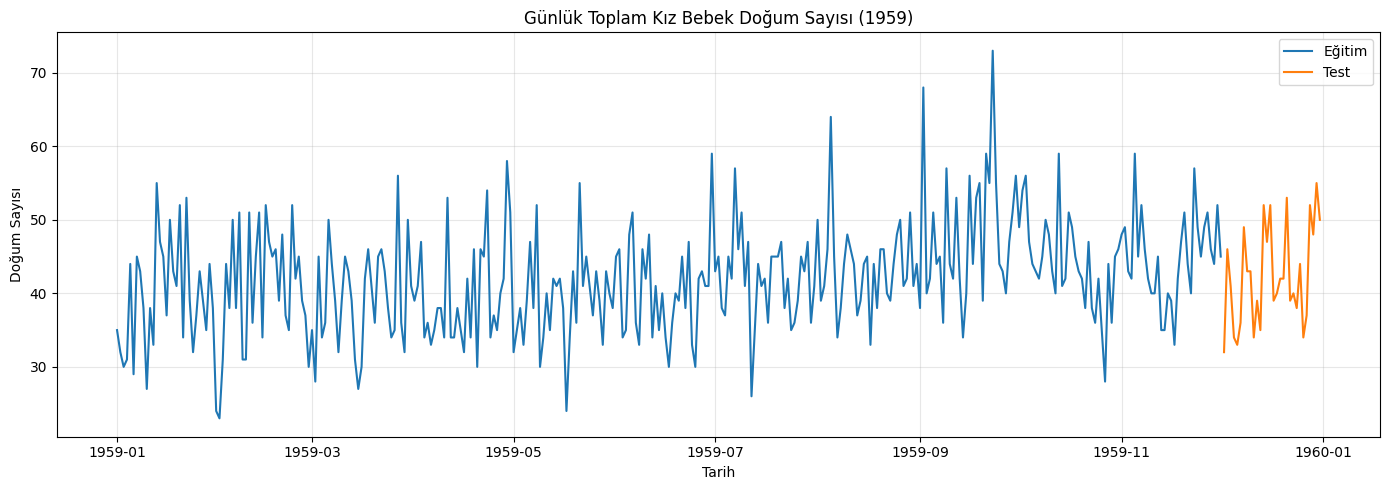

In [4]:
plt.figure(figsize=(14, 5))
plt.plot(train_data.index, train_data['Births'], label='Eğitim')
plt.plot(test_data.index, test_data['Births'], label='Test')
plt.title('Günlük Toplam Kız Bebek Doğum Sayısı (1959)')
plt.xlabel('Tarih')
plt.ylabel('Doğum Sayısı')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Durağanlık Testi (ADF)

In [5]:
# ADF Testi
adf_result = adfuller(train_data['Births'].values, autolag='AIC')

print('ADF Testi Sonuçları:')
print(f'Test İstatistiği: {adf_result[0]:.6f}')
print(f'P-Değeri: {adf_result[1]:.6f}')

if adf_result[1] <= 0.05:
    print('Sonuç: Seri DURAĞAN (fark almaya gerek yok, d=0 olabilir)')
else:
    print('Sonuç: Seri DURAĞAN DEĞİL - Fark alma gerekli')

ADF Testi Sonuçları:
Test İstatistiği: -4.466175
P-Değeri: 0.000226
Sonuç: Seri DURAĞAN (fark almaya gerek yok, d=0 olabilir)


## 3. ACF / PACF Grafikleri

Model derecelerini (p, q) sezgisel olarak belirlemek için kullanılır.

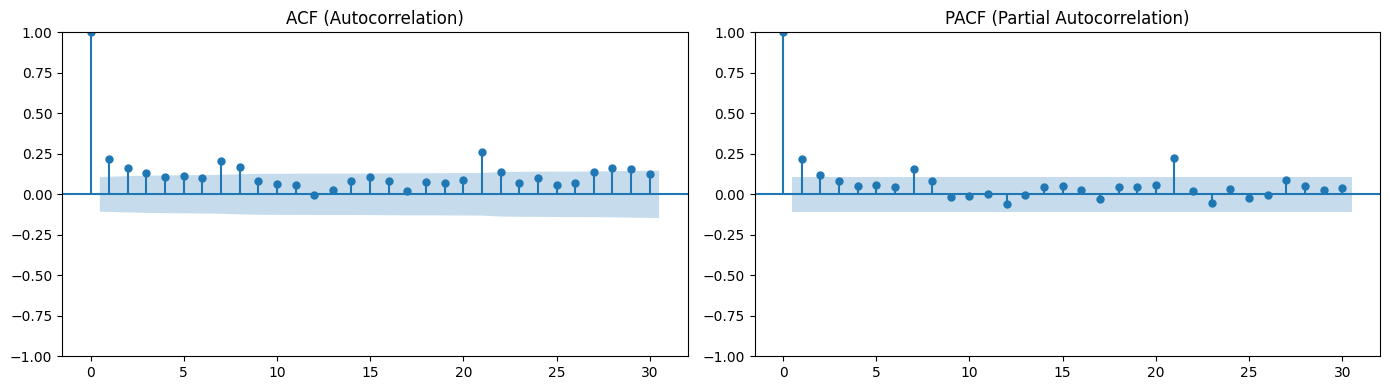

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train_data['Births'], lags=30, ax=axes[0])
axes[0].set_title('ACF (Autocorrelation)')
plot_pacf(train_data['Births'], lags=30, ax=axes[1])
axes[1].set_title('PACF (Partial Autocorrelation)')
plt.tight_layout()
plt.show()

## 4. ARIMA Modeli

`pmdarima.auto_arima` ile en uygun (p,d,q) parametrelerini otomatik arıyoruz.

In [7]:
from pmdarima import auto_arima

print('Optimal ARIMA parametreleri bulunuyor...')
auto_model = auto_arima(
    train_data['Births'],
    seasonal=False,
    max_p=7, max_q=7, max_d=2,
    trace=False,
    suppress_warnings=True
)

print(f'Optimal ARIMA: ARIMA{auto_model.order}')

Optimal ARIMA parametreleri bulunuyor...


Optimal ARIMA: ARIMA(1, 1, 1)


In [8]:
# ARIMA modelini oluştur ve eğit
arima_model = ARIMA(train_data['Births'], order=auto_model.order)
arima_results = arima_model.fit()

print(f'AIC: {arima_results.aic:.2f}')
print(f'BIC: {arima_results.bic:.2f}')

AIC: 2258.67
BIC: 2270.11


In [9]:
# Test verisi üzerinde tahmin
arima_forecast = arima_results.get_forecast(steps=len(test_data))
arima_pred_values = arima_forecast.predicted_mean

arima_rmse = np.sqrt(mean_squared_error(test_data['Births'].values, arima_pred_values.values))
arima_mae = mean_absolute_error(test_data['Births'].values, arima_pred_values.values)

print(f'ARIMA RMSE: {arima_rmse:.2f}')
print(f'ARIMA MAE: {arima_mae:.2f}')

ARIMA RMSE: 7.16
ARIMA MAE: 6.30


## 5. SARIMA Modeli

Doğum sayılarında **haftalık** bir örüntü olabileceğini düşünerek mevsimsel periyodu `m=7` (haftanın 7 günü) seçiyoruz.

In [10]:
print('Optimal SARIMA parametreleri bulunuyor...')
sarima_auto = auto_arima(
    train_data['Births'],
    seasonal=True,
    m=7,
    max_p=3, max_q=3, max_d=2,
    max_P=2, max_Q=2, max_D=1,
    trace=False,
    suppress_warnings=True
)

print(f'Optimal SARIMA: SARIMA{sarima_auto.order}{sarima_auto.seasonal_order}')

Optimal SARIMA parametreleri bulunuyor...


Optimal SARIMA: SARIMA(1, 1, 1)(0, 0, 1, 7)


In [11]:
# SARIMA modelini oluştur ve eğit
sarima_model = SARIMAX(
    train_data['Births'],
    order=sarima_auto.order,
    seasonal_order=sarima_auto.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_results = sarima_model.fit(disp=False)
print(f'AIC: {sarima_results.aic:.2f}')

AIC: 2194.40


In [12]:
# SARIMA tahminleri
sarima_forecast = sarima_results.get_forecast(steps=len(test_data))
sarima_pred_values = sarima_forecast.predicted_mean

sarima_rmse = np.sqrt(mean_squared_error(test_data['Births'].values, sarima_pred_values.values))
sarima_mae = mean_absolute_error(test_data['Births'].values, sarima_pred_values.values)

print(f'SARIMA RMSE: {sarima_rmse:.2f}')
print(f'SARIMA MAE: {sarima_mae:.2f}')

SARIMA RMSE: 7.20
SARIMA MAE: 6.34


## 6. Model Karşılaştırması

In [13]:
results = pd.DataFrame({
    'Model': ['ARIMA', 'SARIMA'],
    'RMSE': [arima_rmse, sarima_rmse],
    'MAE': [arima_mae, sarima_mae]
})

print('Model Karşılaştırması:')
print(results.to_string(index=False))

best_model = results.loc[results['RMSE'].idxmin()]
print(f"\nEn iyi model: {best_model['Model']} (RMSE: {best_model['RMSE']:.2f})")

Model Karşılaştırması:
 Model     RMSE      MAE
 ARIMA 7.159164 6.301262
SARIMA 7.204376 6.335384

En iyi model: ARIMA (RMSE: 7.16)


## 7. Tahminlerin Görselleştirilmesi

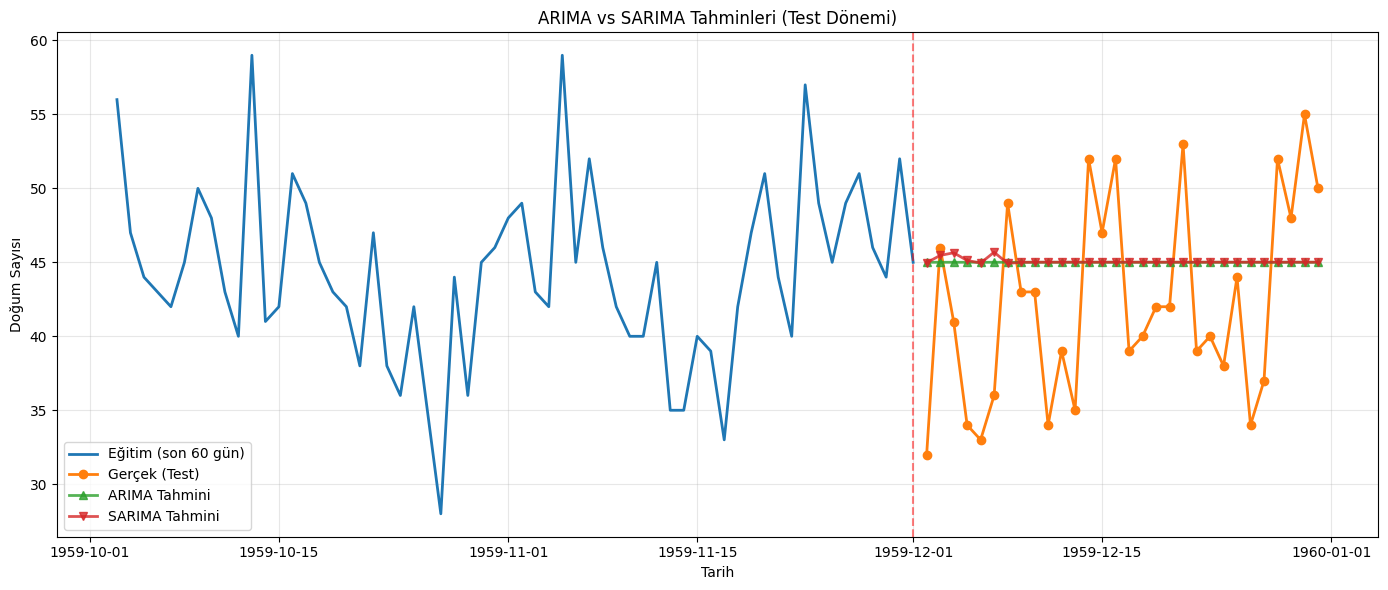

In [14]:
plt.figure(figsize=(14, 6))

plt.plot(train_data.index[-60:], train_data['Births'][-60:], label='Eğitim (son 60 gün)', linewidth=2)
plt.plot(test_data.index, test_data['Births'], label='Gerçek (Test)', marker='o', linewidth=2)
plt.plot(test_data.index, arima_pred_values, label='ARIMA Tahmini', marker='^', linewidth=2, alpha=0.8)
plt.plot(test_data.index, sarima_pred_values, label='SARIMA Tahmini', marker='v', linewidth=2, alpha=0.8)

plt.axvline(x=train_data.index[-1], color='red', linestyle='--', alpha=0.5)
plt.title('ARIMA vs SARIMA Tahminleri (Test Dönemi)')
plt.xlabel('Tarih')
plt.ylabel('Doğum Sayısı')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Gelecek Tahmini

En iyi modeli **tüm veriyle** yeniden eğitip önümüzdeki 14 gün için tahmin üretelim.

In [15]:
# Tüm veriyle SARIMA modelini yeniden eğit
full_model = SARIMAX(
    df['Births'],
    order=sarima_auto.order,
    seasonal_order=sarima_auto.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
full_results = full_model.fit(disp=False)

# 14 günlük tahmin
future_steps = 14
forecast = full_results.get_forecast(steps=future_steps)
forecast_values = forecast.predicted_mean
forecast_ci = forecast.conf_int()

future_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=future_steps, freq='D')

print('Gelecek 14 günlük tahminler:')
for d, val in zip(future_dates, forecast_values):
    print(f'{d.date()}: {val:.1f}')

Gelecek 14 günlük tahminler:
1960-01-01: 44.8
1960-01-02: 42.7
1960-01-03: 43.0
1960-01-04: 44.8
1960-01-05: 44.5
1960-01-06: 45.4
1960-01-07: 44.8
1960-01-08: 44.0
1960-01-09: 43.9
1960-01-10: 43.9
1960-01-11: 43.9
1960-01-12: 43.9
1960-01-13: 43.9
1960-01-14: 43.9


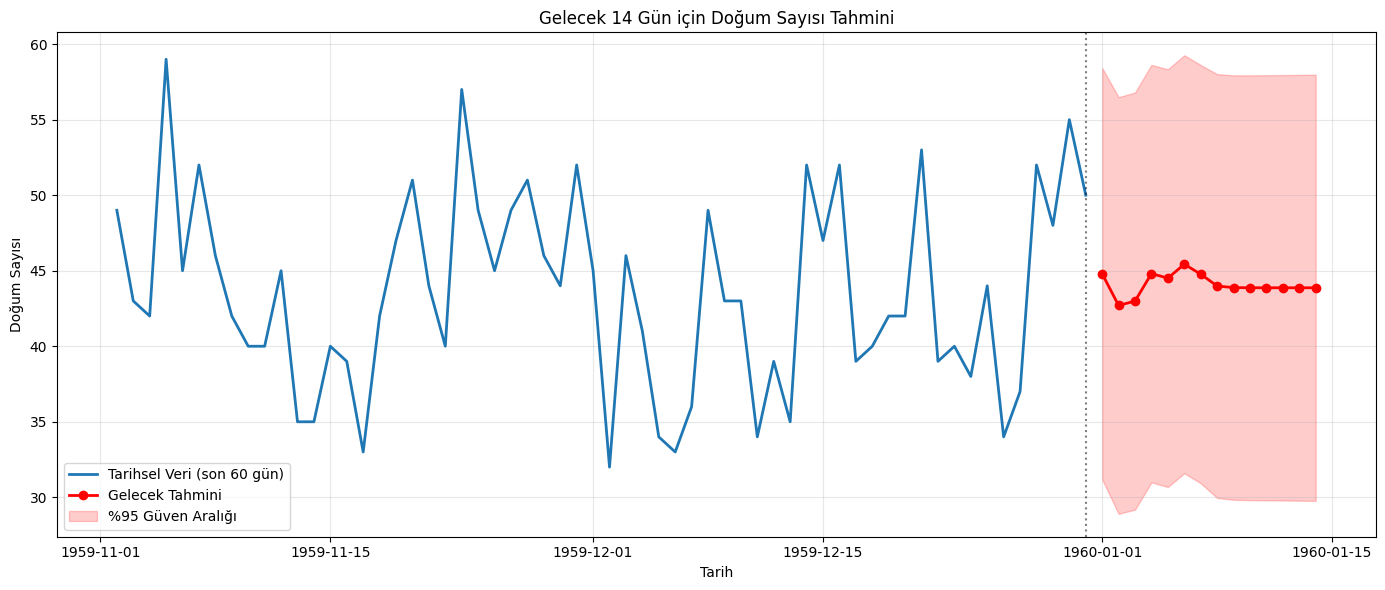

In [16]:
plt.figure(figsize=(14, 6))

plt.plot(df.index[-60:], df['Births'][-60:], label='Tarihsel Veri (son 60 gün)', linewidth=2)
plt.plot(future_dates, forecast_values, label='Gelecek Tahmini', marker='o', linewidth=2, color='red')
plt.fill_between(future_dates, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], alpha=0.2, color='red', label='%95 Güven Aralığı')

plt.axvline(x=df.index[-1], color='black', linestyle=':', alpha=0.5)
plt.title('Gelecek 14 Gün için Doğum Sayısı Tahmini')
plt.xlabel('Tarih')
plt.ylabel('Doğum Sayısı')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Özet

- Veri, ADF testine göre zaten **durağan** çıktığı için (d≈0), hem ARIMA hem SARIMA basit derecelerle kuruldu.
- Haftalık mevsimsellik (m=7) varsayımıyla kurulan **SARIMA**, günlük veri örüntüsünü ARIMA'ya kıyasla ne kadar iyi/kötü yakaladığını RMSE/MAE üzerinden karşılaştırdık.
- Gerçek projelerde bir sonraki adım: farklı mevsimsel periyotları (örn. m=30, m=365) denemek, dışsal değişkenler eklemek (SARIMAX) ve artıkların (residuals) beyaz gürültüye benzeyip benzemediğini Ljung-Box testiyle kontrol etmektir.
